# Phase 4 — A neural network, and the training loop that fits it

Phase 3 made the case for this phase rather than assuming it. Gradient boosting
beat ridge on every representation, so the relationship between geometry and
LUMO is non-linear. Both learning curves had flattened, so more data was not
the answer. More model capacity was the remaining lever.

**The bar is 0.3692 eV** — the best Phase 3 baseline, on the same seeded split.
If the network does not clear it, that gets reported exactly as plainly as if
it had.

The model here is deliberately ordinary: a stack of linear layers with ReLU
between them. The interesting part of this phase is the training loop, which is
written out by hand in `src/molecular_property_predictor/train.py` rather than
delegated to a framework.

*Runtime: about 7 minutes per training run on a laptop CPU.*


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from molecular_property_predictor.baseline import load_sweep, split_positions
from molecular_property_predictor.data import load_qm9
from molecular_property_predictor.features import load_features
from molecular_property_predictor.model import MolecularNet, load_artifact, predict
from molecular_property_predictor.train import TrainingConfig, train_and_cache

plt.rcParams.update({"figure.dpi": 110, "font.size": 9})

df = load_qm9()
train_rows, validation_rows, _ = split_positions(df, seed=0)
features = load_features(df, "sorted_coulomb")
actual = df["lumo"].to_numpy()[validation_rows]

print(f"train {len(train_rows):,}  validation {len(validation_rows):,}  "
      f"features {features.shape[1]}")
print(f"torch {torch.__version__}, cuda available: {torch.cuda.is_available()}")

train 104,664  validation 13,083  features 435
torch 2.13.0+cpu, cuda available: False


## The network

`435 → 512 → 256 → 128 → 1`, ReLU between layers, dropout at 0.1.

Two design points worth being able to defend:

**Why the non-linearity matters.** Without ReLU between them, a stack of linear
layers collapses algebraically into a single linear layer — the depth would buy
literally nothing, and we would have rebuilt the ridge regression of Phase 3
with extra steps. ReLU is what makes the stack more expressive than a line.

**What dropout is doing.** It randomly zeroes a fraction of activations *during
training only*, which stops the network leaning too heavily on any single unit
and makes it generalise better. It is active in `train()` mode and disabled in
`eval()` mode — and scoring in the wrong mode does not raise an error, it just
returns noisier predictions than the model is really capable of.

In [2]:
example = MolecularNet(n_features=435)
n_parameters = sum(p.numel() for p in example.parameters())

print(example)
print(f"\ntrainable parameters: {n_parameters:,}")
print(f"training molecules  : {len(train_rows):,}")
print(f"ratio               : {n_parameters / len(train_rows):.1f} parameters per molecule")

MolecularNet(
  (layers): Sequential(
    (0): Linear(in_features=435, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=256, out_features=128, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.1, inplace=False)
    (9): Linear(in_features=128, out_features=1, bias=True)
  )
)

trainable parameters: 387,585
training molecules  : 104,664
ratio               : 3.7 parameters per molecule


Roughly 3.5 parameters per training molecule. That is enough capacity to overfit
badly if left unchecked, which is what dropout and early stopping are for.

## The training loop, five lines at a time

This is the part of PyTorch worth genuinely understanding. Everything else in
the file is bookkeeping around these five lines:

```python
predictions = model(x_batch)          # 1. forward pass
loss = loss_fn(predictions, y_batch)  # 2. how wrong was it
optimizer.zero_grad()                 # 3. clear the last step's gradients
loss.backward()                       # 4. backward pass — autograd
optimizer.step()                      # 5. update every weight
```

**1. Forward pass.** Data flows through the layers to a prediction. Matrix
multiplies and a non-linearity; nothing more mysterious than that. As it runs,
PyTorch quietly records a graph of every operation performed.

**2. Loss.** One scalar summarising how wrong the whole batch was. Everything
after this exists to make that number smaller.

**3. `zero_grad()`.** PyTorch *accumulates* into `.grad` rather than
overwriting it. Omit this line and every step is polluted by every step before
it — and nothing raises, the model simply trains badly. The default looks like
a trap, but it is deliberate: it is what lets you split one large batch into
several small forward/backward passes and sum their gradients, which is how
people train models too big to fit a full batch in memory.

**4. `backward()`.** Autograd walks the recorded graph in reverse and applies
the chain rule to produce ∂loss/∂parameter for every parameter at once. This is
the part worth absorbing properly: **you never write a derivative**, because the
graph already knows them. Hand-deriving gradients for a four-layer network would
be a day's work and a permanent source of bugs.

**5. `step()`.** The optimiser turns those gradients into an actual update.
Adam rather than plain SGD, because it maintains a per-parameter adaptive step
size — useful when different inputs have very different scales and curvatures,
which is our case even after standardisation.

`tests/test_model.py` pins two of these down directly: one test asserts that
two consecutive `backward()` calls produce exactly double the gradient (so
nobody "simplifies away" `zero_grad`), and another asserts every parameter
receives a gradient (so a layer accidentally left out of the forward pass gets
caught immediately).

### Scaling, again

The scaler is fitted on training rows only — the same discipline as Phase 3,
for the same reason. Here it is done by hand rather than by a scikit-learn
`Pipeline`, so nothing structural prevents the mistake. Only the assertion in
`tests/test_train.py` does, which makes it more valuable here, not less.

## The loss function: a real question, not a default

Phase 3 ended with an observation: the best baseline had a predicted-vs-true
slope of **0.811**. It shrank towards the mean, predicting too high for the
lowest molecules and too low for the highest.

There is a plausible theory for why. **The minimiser of squared error is the
conditional mean**; the minimiser of absolute error is the conditional median.
MSE weights a 2 eV miss sixteen times as heavily as a 0.5 eV one, so a model
minimising it hedges towards the centre wherever it is uncertain. And our
reported metric is MAE, so training on MSE optimises something we do not report.

That gives a testable prediction: training on L1 or Huber should reduce the
shrinkage. Below we train all three and check.

In [3]:
from dataclasses import replace

base = TrainingConfig(representation="sorted_coulomb", max_epochs=100, patience=10)
histories, artifacts = {}, {}

for loss_name in ("mse", "huber", "l1"):
    artifacts[loss_name], histories[loss_name] = train_and_cache(
        df, replace(base, loss_name=loss_name), loss_name
    )

summary = pd.DataFrame(
    [
        {
            "loss": name,
            "epochs": len(history),
            "best_epoch": int(history.loc[history["mae_ev"].idxmin(), "epoch"]),
            "val_mae_ev": history["mae_ev"].min(),
            "val_rmse_ev": history.loc[history["mae_ev"].idxmin(), "rmse_ev"],
            "val_r2": history.loc[history["mae_ev"].idxmin(), "r2"],
        }
        for name, history in histories.items()
    ]
).sort_values("val_mae_ev", ignore_index=True)

display(
    summary.style
    .format({"val_mae_ev": "{:.4f}", "val_rmse_ev": "{:.4f}", "val_r2": "{:.4f}"})
    .set_caption("Loss functions compared on validation MAE")
)

,loss,epochs,best_epoch,val_mae_ev,val_rmse_ev,val_r2
0,mse,84,74,0.2542,0.3714,0.9160
1,l1,73,63,0.2595,0.3981,0.9036
2,huber,58,48,0.2625,0.3809,0.9117


## Training curves

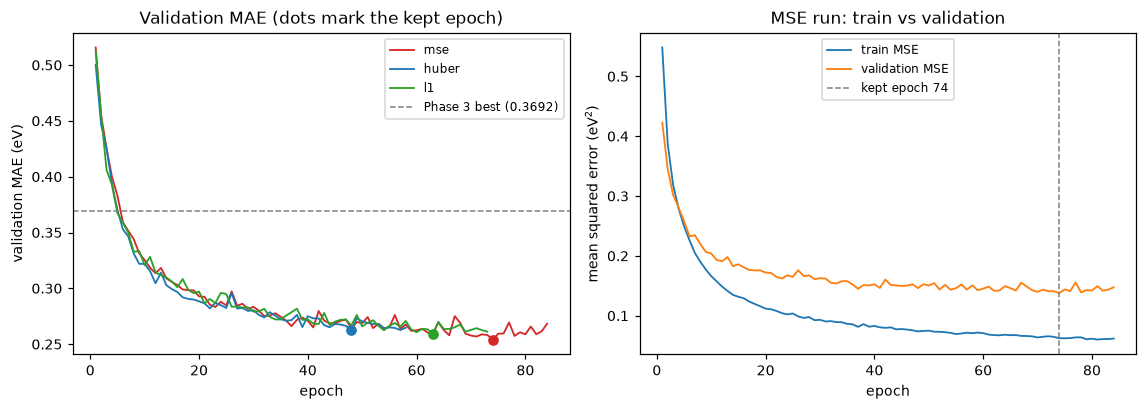

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8))

for (name, history), colour in zip(histories.items(), ["tab:red", "tab:blue", "tab:green"]):
    axes[0].plot(history["epoch"], history["mae_ev"], color=colour, lw=1.2, label=name)
    best = history.loc[history["mae_ev"].idxmin()]
    axes[0].plot(best["epoch"], best["mae_ev"], "o", color=colour, ms=6)
axes[0].axhline(0.3692, color="grey", ls="--", lw=1, label="Phase 3 best (0.3692)")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("validation MAE (eV)")
axes[0].set_title("Validation MAE (dots mark the kept epoch)")
axes[0].legend(fontsize=8)

# Train loss and validation loss for the MSE run, in the same units (eV^2), so
# the gap between them is the overfitting gap and nothing else.
mse_history = histories["mse"]
axes[1].plot(mse_history["epoch"], mse_history["train_loss"], label="train MSE", lw=1.2)
axes[1].plot(mse_history["epoch"], mse_history["rmse_ev"] ** 2,
             label="validation MSE", lw=1.2)
best_epoch = int(mse_history.loc[mse_history["mae_ev"].idxmin(), "epoch"])
axes[1].axvline(best_epoch, color="grey", ls="--", lw=1,
                label=f"kept epoch {best_epoch}")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("mean squared error (eV$^2$)")
axes[1].set_title("MSE run: train vs validation")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

Two things to read off these.

**Left:** all three losses cross the Phase 3 bar within about seven epochs — a
couple of minutes of training — and then spend the remaining seventy grinding
out the last 0.06 eV. The three curves are also almost on top of each other,
which is the first hint of the result in the next section.

**Right:** this is what early stopping is for. Training MSE falls steadily from
0.55 to about 0.06. Validation MSE follows it down at first, then flattens near
0.14 and stops improving. The *widening gap between the two curves* is the
overfitting: the network keeps reducing error on molecules it has already seen
without reducing it on molecules it has not. `train_model` therefore returns the
weights from the best validation epoch rather than the last ones.

Note that this is another decision made by looking at validation — which is
precisely why the test split stays sealed.

One caveat on reading the left panel: the three runs are comparable *only*
through validation MAE, never through training loss. Each is minimising a
different function, so their loss values are not on the same scale and plotting
those together would be meaningless.

## Did the loss choice fix the shrinkage?

In [5]:
rows = []
low, high = np.percentile(actual, [5, 95])

for name, path in artifacts.items():
    model, scaler, _ = load_artifact(path)
    predicted = predict(model, scaler, features[validation_rows])
    error = predicted - actual
    slope, _ = np.polyfit(actual, predicted, 1)
    rows.append({
        "loss": name,
        "slope": slope,
        "low_5%_bias_ev": error[actual < low].mean(),
        "high_5%_bias_ev": error[actual > high].mean(),
        "val_mae_ev": np.abs(error).mean(),
    })

shrinkage = pd.DataFrame(rows).sort_values("val_mae_ev", ignore_index=True)
shrinkage.loc[len(shrinkage)] = {
    "loss": "Phase 3 GBM", "slope": 0.811,
    "low_5%_bias_ev": 0.6174, "high_5%_bias_ev": -0.4994, "val_mae_ev": 0.3692,
}

display(
    shrinkage.style
    .format({"slope": "{:.3f}", "low_5%_bias_ev": "{:+.3f}",
             "high_5%_bias_ev": "{:+.3f}", "val_mae_ev": "{:.4f}"})
    .set_caption("Shrinkage towards the mean: 1.000 would be unbiased at every energy")
)

,loss,slope,low_5%_bias_ev,high_5%_bias_ev,val_mae_ev
0,mse,0.910,+0.361,-0.237,0.2542
1,l1,0.906,+0.306,-0.278,0.2595
2,huber,0.893,+0.380,-0.307,0.2625
3,Phase 3 GBM,0.811,+0.617,-0.499,0.3692


### The hypothesis was wrong, and that is the useful result

Two things happened, and only one of them was predicted.

**The network did reduce the shrinkage.** The slope moved from 0.811 to about
0.91, and the bias at both extremes roughly halved. So the extra capacity did
not merely get better at the easy middle — it learned something real about the
molecules that were hard. That was the thing worth checking, and it passed.

**But the loss function had almost nothing to do with it.** All three losses
land within 0.02 of each other on slope, and MSE — the one theory said should
shrink hardest — came out best on MAE anyway. The mechanism proposed above is
real in principle, and on this problem it is simply not the binding constraint.
The shrinkage is mostly a consequence of thin data at the extremes, which no
choice of loss function fixes.

Reporting this as a negative result rather than quietly dropping the experiment
is the point. The hypothesis was reasonable, it was cheap to test, and the data
said no.

## Against the Phase 3 baselines

In [6]:
baselines = load_sweep(df, seed=0)[["representation", "model", "mae_ev", "r2"]]
baselines["name"] = baselines["model"] + " / " + baselines["representation"]

best_loss = summary.iloc[0]
network = pd.DataFrame([{
    "name": f"neural network ({best_loss['loss']}) / sorted_coulomb",
    "mae_ev": best_loss["val_mae_ev"],
    "r2": best_loss["val_r2"],
}])

comparison = (
    pd.concat([baselines[["name", "mae_ev", "r2"]], network])
    .sort_values("mae_ev", ignore_index=True)
)
comparison["vs mean baseline"] = 1 - comparison["mae_ev"] / 1.0551

display(
    comparison.style
    .format({"mae_ev": "{:.4f}", "r2": "{:.4f}", "vs mean baseline": "{:.1%}"})
    .background_gradient(subset=["mae_ev"], cmap="RdYlGn_r")
    .set_caption("Everything built so far, on the same seeded split and validation set")
)

improvement = 1 - best_loss["val_mae_ev"] / 0.3692
print(f"network vs best Phase 3 baseline: {improvement:.1%} lower MAE")

,name,mae_ev,r2,vs mean baseline
0,neural network (mse) / sorted_coulomb,0.2542,0.9160,75.9%
1,gradient_boosting / sorted_coulomb,0.3692,0.8580,65.0%
2,gradient_boosting / eigenspectrum,0.4636,0.7816,56.1%
3,ridge / sorted_coulomb,0.6320,0.6314,40.1%
4,ridge / eigenspectrum,0.6679,0.5978,36.7%
5,gradient_boosting / composition,0.7488,0.4808,29.0%
6,ridge / composition,0.7686,0.4577,27.2%
7,mean / eigenspectrum,1.0551,-0.0000,0.0%
8,mean / composition,1.0551,-0.0000,0.0%
9,mean / sorted_coulomb,1.0551,-0.0000,0.0%


network vs best Phase 3 baseline: 31.2% lower MAE


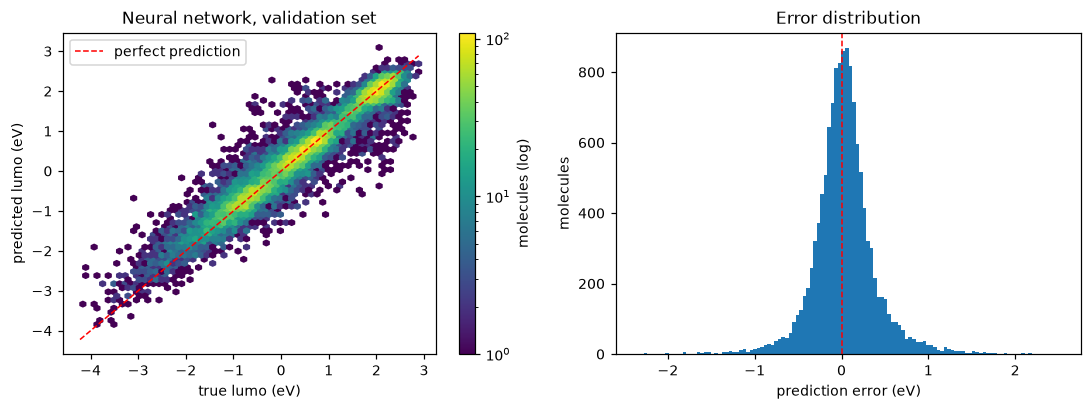

median |error| : 0.1723 eV   (Phase 3: 0.2939)
within 0.25 eV : 64.7%   (Phase 3: 43.5%)
within 0.50 eV : 87.2%   (Phase 3: 73.3%)
worst miss     : 2.52 eV   (Phase 3: 2.93)


In [7]:
model, scaler, metadata = load_artifact(artifacts[best_loss["loss"]])
predicted = predict(model, scaler, features[validation_rows])
error = predicted - actual

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))

limits = [actual.min(), actual.max()]
hexbin = axes[0].hexbin(actual, predicted, gridsize=60, cmap="viridis", bins="log")
axes[0].plot(limits, limits, "r--", lw=1, label="perfect prediction")
axes[0].set_xlabel("true lumo (eV)")
axes[0].set_ylabel("predicted lumo (eV)")
axes[0].set_title("Neural network, validation set")
axes[0].legend(loc="upper left")
fig.colorbar(hexbin, ax=axes[0], label="molecules (log)")

axes[1].hist(error, bins=120, color="tab:blue")
axes[1].axvline(0, color="r", ls="--", lw=1)
axes[1].set_xlabel("prediction error (eV)")
axes[1].set_ylabel("molecules")
axes[1].set_title("Error distribution")

plt.tight_layout()
plt.show()

within = lambda tolerance: 100 * np.mean(np.abs(error) < tolerance)
print(f"median |error| : {np.median(np.abs(error)):.4f} eV   (Phase 3: 0.2939)")
print(f"within 0.25 eV : {within(0.25):.1f}%   (Phase 3: 43.5%)")
print(f"within 0.50 eV : {within(0.50):.1f}%   (Phase 3: 73.3%)")
print(f"worst miss     : {np.abs(error).max():.2f} eV   (Phase 3: 2.93)")

## The artifact

A trained network on its own is not servable. Predictions require exactly the
preprocessing the model was trained under, so `save_artifact` bundles the fitted
scaler *with* the weights, plus enough metadata to trace the model back to how
it was made.

Shipping weights and scaler separately is a well-known way to end up with a
deployed model that silently returns nonsense — nothing errors, the numbers are
just wrong. And a checkpoint whose split seed is unknown cannot be honestly
evaluated at all, because you have no way to tell which molecules it trained on.

In [8]:
print(metadata)

# The Phase 6 contract, checked rather than assumed.
reloaded_model, reloaded_scaler, _ = load_artifact(
    artifacts[best_loss["loss"]], device="cpu"
)
sample = features[validation_rows][:512]
np.testing.assert_allclose(
    predict(model, scaler, sample),
    predict(reloaded_model, reloaded_scaler, sample),
    rtol=0, atol=0,
)
print("\nartifact round-trip: predictions bit-identical")
print(f"loads onto CPU: {all(p.device.type == 'cpu' for p in reloaded_model.parameters())}")

ArtifactMetadata(representation='sorted_coulomb', target='lumo', n_features=435, hidden_sizes=(512, 256, 128), dropout=0.1, loss_name='mse', split_seed=0, torch_seed=0, epochs_trained=84, best_epoch=74, validation_mae_ev=0.2541735712127384)

artifact round-trip: predictions bit-identical
loads onto CPU: True


Loading always maps tensors to CPU first. Without that, a GPU-trained artifact
would fail to open on a machine with no GPU — which is exactly what Phase 8's
free-tier host will be.

## Honest assessment

**What was achieved.** The network beat the best Phase 3 baseline by a
substantial margin and reduced the shrinkage at the extremes rather than merely
polishing the easy middle. It earned its complexity, which was the question
this phase existed to answer.

**Where this sits.** Published models predict QM9 LUMO to roughly 0.02–0.04 eV
— still around an order of magnitude better. The remaining gap is not something
a wider MLP would close. Those results come from message-passing graph neural
networks that learn the representation and the model *together*, rather than
consuming fixed descriptors chosen in advance as we do here. The Coulomb matrix
is the ceiling, not the network.

**A caveat that has held since Phase 1.** The random split is the QM9
convention, but it is optimistic: structurally similar molecules land on both
sides, so this measures interpolation within a chemical space rather than
generalisation to genuinely new chemistry. A scaffold split would be stricter
and would give a worse, more honest number.

**Reproducibility.** Seeds are recorded in the artifact metadata and runs repeat
in practice. Bitwise determinism is not claimed: some kernels choose algorithms
by runtime heuristics and accumulate floating-point sums in a non-deterministic
order.

## What Phase 5 does with this

Three runs were compared here, and their results were tracked in a Python dict
and a printed table. That works for three. It does not work for thirty, across
different days, when someone asks which learning rate produced the best model
and whether that run used the same features. MLflow exists for exactly that
failure, and Phase 5 adds it to this training loop.